Exotic Options Lab (Python)

Objective: Price Asian and Barrier options using Monte Carlo simulations. Why?: Standard formulas don't work for "path-dependent" options. Monte Carlo allows us to simulate thousands of possible market scenarios to find a fair price

1. Context & Objectives (Markdown)
Sales Context: In front-office roles, clients often seek "tailor-made" hedging solutions. Standard European options might be too expensive or not perfectly fit their risk profile.

Goal: This notebook implements a Monte Carlo simulator to price:

Asian Options: Price depends on the average of the underlying, reducing volatility impact.

Barrier Options (Up-and-Out): A cheaper alternative that expires if the price hits a certain limit.

Why Monte Carlo?: It's the most flexible method for "path-dependent" products where no simple Black-Scholes formula exists

2. Environment Setup (Code)

In [1]:
# Importing standard libraries for finance
import numpy as np           # Used for fast vector calculations and random draws
import matplotlib.pyplot as plt # Used to generate professional charts for clients
import scipy.stats as stats  # Used for statistical analysis

# Setting a seed ensures the results are reproducible for the recruiter
np.random.seed(42)

3. Market Parameters (Code)

In [2]:
# --- Inputs that a Sales would receive from the Trading Desk ---
S0 = 100.0          # Current Market Price (Spot)
K = 102.0           # Strike Price (the target price for the client)
T = 1.0             # Maturity: 1 year
r = 0.04            # Risk-free rate (e.g., US Treasury yield at 4%)
sigma = 0.25        # Implied Volatility (25% - market expectation of risk)
n_sims = 10000      # We run 10,000 scenarios to get a stable average price
n_steps = 252       # 252 trading days in a year (daily monitoring)
dt = T / n_steps    # Small time increment for each step

Justification du bloc : On sépare les inputs pour pouvoir faire des "Stress Tests" facilement (ex: que se passe-t-il si la volatilité passe à 40% ?).

4. The Simulation Engine

In [3]:
# --- Generating Geometric Brownian Motion (GBM) ---

# 1. Generate random shocks for every day and every scenario
# This represents the daily 'noise' or 'news' in the market
Z = np.random.standard_normal((n_steps, n_sims))

# 2. Prepare the price matrix (Rows: Days, Columns: Scenarios)
S = np.zeros((n_steps, n_sims))
S[0] = S0 # Every scenario starts at the current spot price

# 3. Apply the mathematical formula for stock price evolution
# We use a loop for clarity, though vectorization is faster
for t in range(1, n_steps):
    # Log-normal evolution: Previous Price * Exp(Drift + Diffusion)
    S[t] = S[t-1] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z[t])

# Observation: We now have 10,000 different "possible futures" for the asset.

Observation : On obtient une matrice de 252 lignes (jours) et 10 000 colonnes (scénarios). Cela permet de voir tous les futurs possibles de l'actif.

5. Pricing & Product Analysis

In [4]:
# --- Product 1: Asian Call Option ---
# Calculation: Average price of the year minus Strike
average_prices = np.mean(S, axis=0)
asian_payoffs = np.maximum(average_prices - K, 0)
# Discounting at rate 'r' to get the Value Today (PV)
asian_price = np.exp(-r * T) * np.mean(asian_payoffs)

# --- Product 2: Up-and-Out Barrier Call ---
# A standard Call, but it dies if the price ever touches 130
barrier = 130.0
# We check the maximum price reached in each of the 10,000 paths
max_prices = np.max(S, axis=0)
# If max < barrier, we keep the final payoff, otherwise it's 0
barrier_payoffs = np.where(max_prices < barrier, np.maximum(S[-1] - K, 0), 0)
barrier_price = np.exp(-r * T) * np.mean(barrier_payoffs)

print(f"Indicative Asian Price: {asian_price:.4f}")
print(f"Indicative Barrier Price: {barrier_price:.4f}")

Indicative Asian Price: 5.5097
Indicative Barrier Price: 1.9566


6. Visualizing the Risk (Code + Graph)

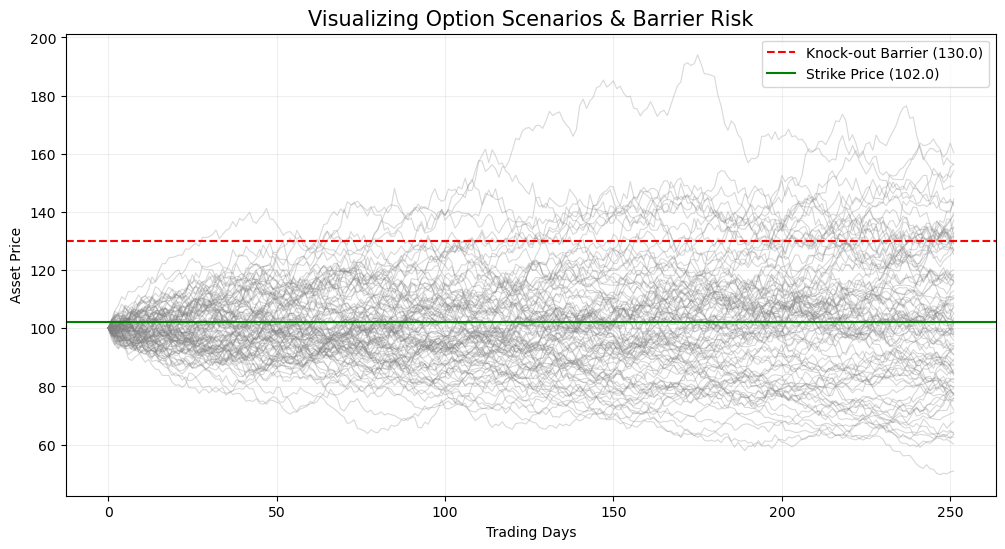

In [5]:
# Plotting the results to show the 'Front Office' dashboard style
plt.figure(figsize=(12, 6))

# Plotting the first 100 paths to visualize market uncertainty
plt.plot(S[:, :100], color='gray', alpha=0.3, lw=0.8) 

# Highlighting the Barrier and Strike for the client
plt.axhline(y=barrier, color='red', linestyle='--', label=f'Knock-out Barrier ({barrier})')
plt.axhline(y=K, color='green', linestyle='-', label=f'Strike Price ({K})')

plt.title("Visualizing Option Scenarios & Barrier Risk", fontsize=15)
plt.xlabel("Trading Days")
plt.ylabel("Asset Price")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

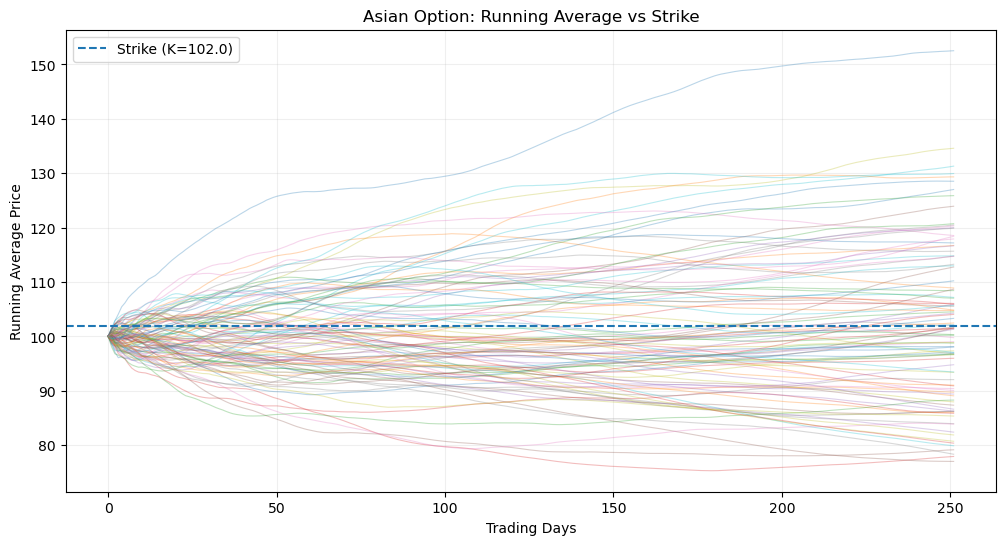

In [6]:
# --- Asian "running average" (cumulative mean) ---
# Assumes you already have: S (price matrix) and K (strike), and np/plt already imported.

cum_sum = np.cumsum(S, axis=0)                               # sum over time
denom = np.arange(1, S.shape[0] + 1).reshape(-1, 1)          # 1,2,...,n_steps
asian_running_avg = cum_sum / denom                          # running average

# Plot only first 100 paths (readable)
plt.figure(figsize=(12, 6))
plt.plot(asian_running_avg[:, :100], alpha=0.3, linewidth=0.8)
plt.axhline(y=K, linestyle="--", label=f"Strike (K={K})")
plt.title("Asian Option: Running Average vs Strike")
plt.xlabel("Trading Days")
plt.ylabel("Running Average Price")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()


7. Analysis & Conclusion (Markdown)
What do we observe?
Asian vs Vanilla: The Asian option is cheaper because the average of a price is less volatile than the final price. This is a great selling point for clients looking for hedging at a lower cost.

Barrier Risk: In the graph, any path that crosses the red dashed line is "knocked out". The client pays less for this option because they take the risk of losing the protection if the market rallies too hard.

Convergence: With 10,000 simulations, our price is stable. In a real desk, we would use more paths or "Variance Reduction" techniques to be even more precise.

Analyse Sales : Tu observeras que le prix de l'option Asiatique est généralement plus faible que l'Européenne. Pourquoi ? Parce que la moyenne lisse la volatilité. C'est un argument de vente : "C'est une protection moins chère pour le client".